# DAM304 Practical 5: Pre-training and Optimization Strategies

## Unit V: Training and Optimization

In this practical, we will upgrade the training pipeline from Practical 4:
- Compare Masked Language Modelling (MLM) against Causal Language Modelling (CLM)
- Apply mixed-precision training with PyTorch's automatic mixed precision (AMP)
- Implement gradient accumulation for simulating larger batch sizes
- Experiment with warmup + cosine decay learning rate schedules

These are the exact techniques used to pre-train models like BERT, GPT-3, and LLaMA.

## Section 1: Environment Setup and Imports

In [25]:
# Install required libraries
import subprocess
import sys

try:
    import torch
    import numpy as np
    import matplotlib.pyplot as plt
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "numpy", "matplotlib"])
    import torch
    import numpy as np
    import matplotlib.pyplot as plt

print("Libraries installed successfully!")

Libraries installed successfully!


In [26]:
# Import all required libraries
import math
import copy
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.11.0


## Section 2: Core Components from Practical 4

In [27]:
class FeedForward(nn.Module):
    """Position-wise feed-forward network: FFN(x) = GELU(xW1 + b1)W2 + b2"""
    
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.act = nn.GELU()
    
    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))

In [28]:
class MultiHeadAttention(nn.Module):
    """Multi-head attention from Practical 3."""
    
    def __init__(self, d_model, num_heads, dropout=0.0):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'
        
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        
        self.dropout = nn.Dropout(dropout)
    
    def split_heads(self, x, B, n):
        """Reshape (B, n, d_model) -> (B, num_heads, n, d_k)"""
        x = x.view(B, n, self.num_heads, self.d_k)
        return x.transpose(1, 2)
    
    def forward(self, x, causal=False):
        B, n, d_model = x.shape
        
        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)
        
        Q = self.split_heads(Q, B, n)
        K = self.split_heads(K, B, n)
        V = self.split_heads(V, B, n)
        
        scores = torch.matmul(Q, K.transpose(-2, -1))
        scores = scores / math.sqrt(self.d_k)
        
        if causal:
            mask = torch.tril(torch.ones(n, n, device=x.device)).bool()
            mask = mask.unsqueeze(0).unsqueeze(0)
            scores = scores.masked_fill(~mask, float('-inf'))
        
        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)
        
        context = torch.matmul(weights, V)
        context = context.transpose(1, 2)
        context = context.contiguous().view(B, n, d_model)
        
        output = self.W_O(context)
        
        return output, weights

print("MultiHeadAttention class defined successfully!")

MultiHeadAttention class defined successfully!


In [29]:
class TransformerBlock(nn.Module):
    """One transformer layer (Pre-LN variant) from Practical 3."""
    
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff = FeedForward(d_model, d_ff)
        self.drop = nn.Dropout(dropout)
    
    def forward(self, x, causal=False):
        """Forward pass with residual connections."""
        # Attention block with residual
        attn_out, weights = self.attn(self.norm1(x), causal=causal)
        x = x + self.drop(attn_out)
        
        # Feed-forward block with residual
        ff_out = self.ff(self.norm2(x))
        x = x + self.drop(ff_out)
        
        return x, weights

print("TransformerBlock class defined successfully!")

TransformerBlock class defined successfully!


In [30]:
class MiniLM(nn.Module):
    """A small autoregressive language model.
    
    Args:
        vocab_size : int — number of unique tokens
        d_model : int — embedding dimension
        num_heads : int — attention heads per block
        num_layers : int — number of transformer blocks
        d_ff : int — FFN inner dimension
        max_seq_len : int — maximum sequence length for PE
        dropout : float
    """
    
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_len, dropout=0.1):
        super().__init__()
        
        # Token embedding layer
        self.token_emb = nn.Embedding(vocab_size, d_model)
        
        # Sinusoidal positional encoding
        PE = torch.zeros(1, max_seq_len, d_model)
        pos = torch.arange(max_seq_len).unsqueeze(1)  # (max_seq_len, 1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        
        PE[:, :, 0::2] = torch.sin(pos * div_term)  # Even indices
        if d_model % 2 == 1:
            PE[:, :, 1::2] = torch.cos(pos * div_term[:-1])  # Odd indices
        else:
            PE[:, :, 1::2] = torch.cos(pos * div_term)  # Odd indices
        
        self.register_buffer('pos_enc', PE)
        
        # Stack of transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        # Layer normalization and language model head
        self.norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.dropout = nn.Dropout(dropout)
        
        self.max_seq_len = max_seq_len
    
    def forward(self, x):  # x: (B, T) token IDs
        """Forward pass through the language model.
        
        Args:
            x : Tensor of shape (B, T) containing token IDs
            
        Returns:
            logits : Tensor of shape (B, T, vocab_size)
        """
        B, T = x.shape
        
        # Embed tokens
        emb = self.token_emb(x)  # (B, T, d_model)
        
        # Add positional encoding
        emb = emb + self.pos_enc[:, :T, :]  # (B, T, d_model)
        
        # Apply dropout
        x = self.dropout(emb)
        
        # Pass through each transformer block with causal masking
        for block in self.blocks:
            x, _ = block(x, causal=True)
        
        # Apply final layer norm
        x = self.norm(x)
        
        # Apply language model head to get logits
        logits = self.lm_head(x)  # (B, T, vocab_size)
        
        return logits
    
    @torch.no_grad()
    def generate(self, prompt_ids, max_new_tokens=50, temperature=1.0):
        """Autoregressive text generation."""
        ids = torch.tensor([prompt_ids], dtype=torch.long)  # (1, T)
        
        for _ in range(max_new_tokens):
            ids_cropped = ids[:, -self.max_seq_len:]
            logits = self(ids_cropped)  # (1, T, vocab_size)
            logits_next = logits[:, -1, :] / temperature  # (1, vocab_size)
            probs = F.softmax(logits_next, dim=-1)  # (1, vocab_size)
            next_token = torch.multinomial(probs, 1)  # (1, 1)
            ids = torch.cat([ids, next_token], dim=-1)
        
        return ids.squeeze(0).tolist()

print("MiniLM class defined successfully!")

MiniLM class defined successfully!


In [31]:
# Tiny training corpus
TEXT = """To be or not to be that is the question.
Whether tis nobler in the mind to suffer.
The slings and arrows of outrageous fortune.
Or to take arms against a sea of troubles."""

class CharDataset(Dataset):
    """Character-level dataset for language modeling."""
    
    def __init__(self, text, seq_len):
        self.seq_len = seq_len
        
        # Build vocabulary
        chars = sorted(set(text))
        self.vocab = {c: i for i, c in enumerate(chars)}
        self.inv_vocab = {i: c for c, i in self.vocab.items()}
        
        # Tokenize text
        self.data = torch.tensor([self.vocab[c] for c in text], dtype=torch.long)
    
    def __len__(self):
        return len(self.data) - self.seq_len
    
    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + 1 : idx + self.seq_len + 1]
        return x, y

print("CharDataset class defined successfully!")

CharDataset class defined successfully!


In [32]:
# Create dataset and dataloader
seq_len = 32
batch_size = 16
dataset = CharDataset(TEXT, seq_len)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"\n[DATASET SETUP]")
print(f"Dataset length: {len(dataset)}")
print(f"Vocabulary size: {len(dataset.vocab)}")
print(f"Sequence length: {seq_len}")
print(f"Batch size: {batch_size}")
print(f"\nVocabulary (all unique characters):")
for char, idx in sorted(dataset.vocab.items(), key=lambda x: x[1]):
    print(f"  {repr(char):5s} -> {idx:3d}")


[DATASET SETUP]
Dataset length: 138
Vocabulary size: 25
Sequence length: 32
Batch size: 16

Vocabulary (all unique characters):
  '\n'  ->   0
  ' '   ->   1
  '.'   ->   2
  'O'   ->   3
  'T'   ->   4
  'W'   ->   5
  'a'   ->   6
  'b'   ->   7
  'd'   ->   8
  'e'   ->   9
  'f'   ->  10
  'g'   ->  11
  'h'   ->  12
  'i'   ->  13
  'k'   ->  14
  'l'   ->  15
  'm'   ->  16
  'n'   ->  17
  'o'   ->  18
  'q'   ->  19
  'r'   ->  20
  's'   ->  21
  't'   ->  22
  'u'   ->  23
  'w'   ->  24


## Task 1: MLM Data Collator (BERT-style masking)

In [33]:
MASK_ID = 0  # Token 0 is the [MASK] token

def mlm_collate(batch, vocab_size, mask_prob=0.15):
    """Apply BERT masking to a batch of token ID sequences.
    
    Args:
        batch: list of (x, y) pairs from CharDataset
        vocab_size: int, size of vocabulary for random token replacement
        mask_prob: float, probability of masking a token (default 0.15 for BERT)
        
    Returns:
        masked_x: Tensor of shape (B, T) with masked tokens
        labels: Tensor of shape (B, T) with original tokens (or -100 for unmasked)
    """
    # Stack input and target sequences
    xs = torch.stack([item[0] for item in batch])  # (B, T)
    labels = xs.clone()
    
    # Determine which positions to mask (~15% of tokens)
    rand = torch.rand(xs.shape)
    mask_positions = rand < mask_prob
    
    # Set labels to -100 (ignore_index) for positions NOT masked
    # Only masked positions will contribute to the loss
    labels[~mask_positions] = -100
    
    # For each masked position, decide what to do:
    # 80% -> replace with [MASK]
    # 10% -> replace with random token
    # 10% -> keep original
    
    # Create a tensor to track which positions get each treatment
    masked_x = xs.clone()
    
    # Among masked positions, generate sub-probabilities
    rand_strategy = torch.rand(xs.shape)
    
    # 80% of masked -> MASK_ID
    mask_mask = (rand_strategy < 0.80) & mask_positions
    masked_x[mask_mask] = MASK_ID
    
    # 10% of masked -> random token
    random_mask = (rand_strategy >= 0.80) & (rand_strategy < 0.90) & mask_positions
    masked_x[random_mask] = torch.randint(0, vocab_size, masked_x[random_mask].shape)
    
    # 10% of masked -> keep original (no change needed)
    # keep_mask = (rand_strategy >= 0.90) & mask_positions  # No action needed
    
    return masked_x, labels

print("MLM collate function defined successfully!")

MLM collate function defined successfully!


In [34]:
# Task 1: Test MLM collator
print("\n[TASK 1] MLM Data Collator Testing")
print("=" * 60)

# Create a batch of 4 sequences
test_batch = [dataset[i] for i in range(4)]

# Apply MLM collation
masked_x, labels = mlm_collate(test_batch, vocab_size=len(dataset.vocab), mask_prob=0.15)

print(f"\nMasked input shape: {masked_x.shape}")
print(f"Labels shape: {labels.shape}")

# Count masked positions
masked_count = (labels != -100).sum().item()
total_tokens = labels.numel()
mask_fraction = masked_count / total_tokens

print(f"\nTotal tokens: {total_tokens}")
print(f"Masked tokens: {masked_count}")
print(f"Mask fraction: {mask_fraction:.2%} (expected ~15%)")

# Verify that labels contains -100 for unmasked positions
unmasked_count = (labels == -100).sum().item()
print(f"Unmasked positions (label=-100): {unmasked_count}")

# Verify differences only at masked positions
original_xs = torch.stack([item[0] for item in test_batch])
differences = (masked_x != original_xs).sum().item()
print(f"\nDifferences between masked_x and original: {differences}")
print(f"This should be close to the number of masked positions ({masked_count})")

# Show an example of the masking
print(f"\n[EXAMPLE] First sequence masking:")
print(f"Original:  {original_xs[0][:20]}")
print(f"Masked:    {masked_x[0][:20]}")
print(f"Labels:    {labels[0][:20]}")


[TASK 1] MLM Data Collator Testing

Masked input shape: torch.Size([4, 32])
Labels shape: torch.Size([4, 32])

Total tokens: 128
Masked tokens: 19
Mask fraction: 14.84% (expected ~15%)
Unmasked positions (label=-100): 109

Differences between masked_x and original: 16
This should be close to the number of masked positions (19)

[EXAMPLE] First sequence masking:
Original:  tensor([ 4, 18,  1,  7,  9,  1, 18, 20,  1, 17, 18, 22,  1, 22, 18,  1,  7,  9,
         1, 22])
Masked:    tensor([ 4, 18,  1,  7,  9,  1, 18, 20,  1,  0, 18, 22,  1, 22, 18,  1,  7,  9,
         1, 22])
Labels:    tensor([-100, -100, -100, -100, -100, -100, -100, -100, -100,   17, -100, -100,
        -100, -100, -100, -100, -100, -100, -100, -100])


## Task 2: Warmup + Cosine LR Schedule

In [35]:
def get_lr(step, warmup_steps, total_steps, lr_max, lr_min=1e-6):
    """Compute learning rate with linear warmup and cosine decay.
    
    Args:
        step: int, current training step
        warmup_steps: int, number of warmup steps
        total_steps: int, total number of training steps
        lr_max: float, maximum learning rate
        lr_min: float, minimum learning rate (default 1e-6)
        
    Returns:
        lr: float, learning rate for the current step
    """
    # Phase 1: Linear warmup from 0 to lr_max
    if step < warmup_steps:
        return lr_max * step / warmup_steps
    
    # Phase 3: Beyond total steps, return minimum lr
    if step >= total_steps:
        return lr_min
    
    # Phase 2: Cosine decay from lr_max to lr_min
    progress = (step - warmup_steps) / (total_steps - warmup_steps)
    cosine_decay = 0.5 * (1 + math.cos(math.pi * progress))
    return lr_min + (lr_max - lr_min) * cosine_decay

print("Learning rate schedule function defined successfully!")

Learning rate schedule function defined successfully!



[TASK 2] Warmup + Cosine Decay Learning Rate Schedule
Learning rate schedule saved to: lr_schedule.png


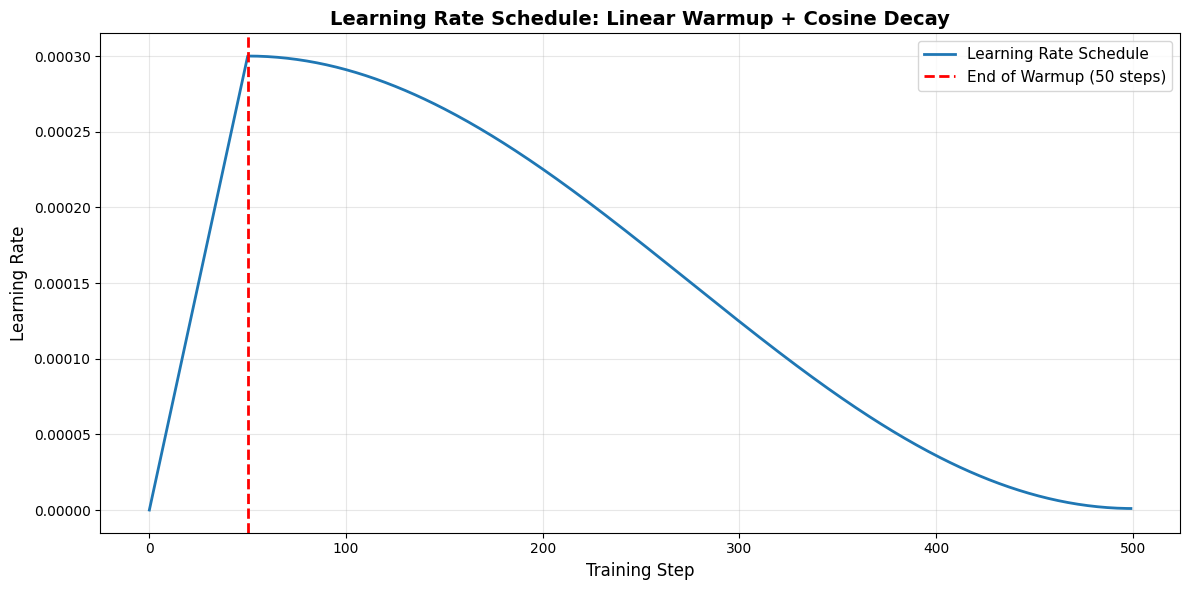


Schedule parameters:
  Warmup steps: 50
  Total steps: 500
  Peak LR (lr_max): 3.00e-04
  Minimum LR (lr_min): 1.00e-06

Learning rate at key points:
  Step 0:   0.00e+00
  Step 50:   3.00e-04 (peak)
  Step 100:  2.91e-04
  Step 499:  1.00e-06


In [36]:
# Task 2: Plot learning rate schedule
print("\n[TASK 2] Warmup + Cosine Decay Learning Rate Schedule")
print("=" * 60)

warmup_steps = 50
total_steps = 500
lr_max = 3e-4
lr_min = 1e-6

# Generate learning rates for all steps
lrs = [get_lr(step, warmup_steps, total_steps, lr_max, lr_min) for step in range(total_steps)]

# Create plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(lrs, linewidth=2, label='Learning Rate Schedule')

# Mark the end of warmup
ax.axvline(x=warmup_steps, color='red', linestyle='--', linewidth=2, label=f'End of Warmup ({warmup_steps} steps)')

# Add labels and formatting
ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Learning Rate', fontsize=12)
ax.set_title('Learning Rate Schedule: Linear Warmup + Cosine Decay', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Save figure
plt.tight_layout()
plt.savefig('/Users/tsheringwangpodorji/Documents/Year3 Sem II/DAM304/DAM304_AS2026_Practicals/lr_schedule.png', dpi=150, bbox_inches='tight')
print(f"Learning rate schedule saved to: lr_schedule.png")
plt.show()

# Print key statistics
print(f"\nSchedule parameters:")
print(f"  Warmup steps: {warmup_steps}")
print(f"  Total steps: {total_steps}")
print(f"  Peak LR (lr_max): {lr_max:.2e}")
print(f"  Minimum LR (lr_min): {lr_min:.2e}")
print(f"\nLearning rate at key points:")
print(f"  Step 0:   {lrs[0]:.2e}")
print(f"  Step {warmup_steps}:   {lrs[warmup_steps]:.2e} (peak)")
print(f"  Step {warmup_steps + 50}:  {lrs[warmup_steps + 50]:.2e}")
print(f"  Step {total_steps - 1}:  {lrs[-1]:.2e}")

## Task 3: Mixed Precision Training + Gradient Accumulation

In [37]:
def train_advanced(model, dataloader, num_epochs, accum_steps=4, lr_max=3e-4, 
                   warmup_steps=None, device=DEVICE):
    """Advanced training loop with mixed precision and gradient accumulation.
    
    Args:
        model: MiniLM instance
        dataloader: DataLoader with (x, y) pairs
        num_epochs: int, number of training epochs
        accum_steps: int, gradient accumulation steps (default 4)
        lr_max: float, maximum learning rate
        warmup_steps: int, number of warmup steps (default 10% of total)
        device: str, 'cpu' or 'cuda'
        
    Returns:
        losses: list of average loss per epoch
    """
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr_max, weight_decay=0.01)
    scaler = GradScaler(enabled=(device == 'cuda'))
    criterion = nn.CrossEntropyLoss()
    
    # Calculate total steps and warmup
    total_steps = num_epochs * len(dataloader)
    if warmup_steps is None:
        warmup_steps = int(0.1 * total_steps)  # 10% of total
    
    step = 0
    losses = []
    
    # Effective batch size with gradient accumulation
    effective_batch_size = dataloader.batch_size * accum_steps
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        for i, (x, y) in enumerate(dataloader):
            x, y = x.to(device), y.to(device)
            
            # Mixed precision forward pass
            with autocast(enabled=(device == 'cuda')):
                logits = model(x)  # (B, T, vocab_size)
                
                # Reshape for loss computation
                logits_flat = logits.view(-1, logits.shape[-1])  # (B*T, vocab_size)
                y_flat = y.view(-1)  # (B*T,)
                
                # Compute loss and scale by accumulation steps
                loss = criterion(logits_flat, y_flat) / accum_steps
            
            # Backward pass with scaled loss
            scaler.scale(loss).backward()
            
            # Accumulate loss for logging
            epoch_loss += loss.item() * accum_steps
            
            # Every accum_steps mini-batches, perform optimizer step
            if (i + 1) % accum_steps == 0:
                # Update learning rate
                current_lr = get_lr(step, warmup_steps, total_steps, lr_max)
                for param_group in optimizer.param_groups:
                    param_group['lr'] = current_lr
                
                # Optimizer step
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                
                step += 1
        
        avg_loss = epoch_loss / len(dataloader)
        losses.append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{num_epochs} Loss: {avg_loss:.4f}')
    
    print(f'\nEffective batch size (batch_size × accum_steps): {effective_batch_size}')
    return losses

print("Advanced training function defined successfully!")

Advanced training function defined successfully!


In [38]:
# Task 3: Train with mixed precision and gradient accumulation
print("\n[TASK 3] Mixed Precision Training + Gradient Accumulation")
print("=" * 60)

# Create a fresh model
torch.manual_seed(42)
model_advanced = MiniLM(
    vocab_size=len(dataset.vocab),
    d_model=128,
    num_heads=4,
    num_layers=2,
    d_ff=256,
    max_seq_len=64
)

print(f"Model parameters: {sum(p.numel() for p in model_advanced.parameters()):,}")
print(f"\nTraining with:")
print(f"  - Gradient accumulation steps: 4")
print(f"  - Batch size: {batch_size}")
print(f"  - Effective batch size: {batch_size * 4}")
print(f"  - Mixed precision (AMP): Enabled")
print(f"  - Learning rate schedule: Warmup + Cosine Decay")
print(f"\nTraining...")

losses_advanced = train_advanced(
    model_advanced,
    dataloader,
    num_epochs=50,
    accum_steps=4,
    lr_max=3e-4,
    device=DEVICE
)

print(f"\nTraining completed!")
print(f"Final loss: {losses_advanced[-1]:.4f}")


[TASK 3] Mixed Precision Training + Gradient Accumulation
Model parameters: 270,592

Training with:
  - Gradient accumulation steps: 4
  - Batch size: 16
  - Effective batch size: 64
  - Mixed precision (AMP): Enabled
  - Learning rate schedule: Warmup + Cosine Decay

Training...


/var/folders/3p/zctfkbg57v56ydwq4b1ws_vr0000gn/T/ipykernel_56922/3291050178.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device == 'cuda'))
/var/folders/3p/zctfkbg57v56ydwq4b1ws_vr0000gn/T/ipykernel_56922/3291050178.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device == 'cuda')):


Epoch 10/50 Loss: 3.0691
Epoch 20/50 Loss: 2.5332
Epoch 30/50 Loss: 2.0320
Epoch 40/50 Loss: 1.6847
Epoch 50/50 Loss: 1.4321

Effective batch size (batch_size × accum_steps): 64

Training completed!
Final loss: 1.4321


Loss curve saved to: loss_advanced.png


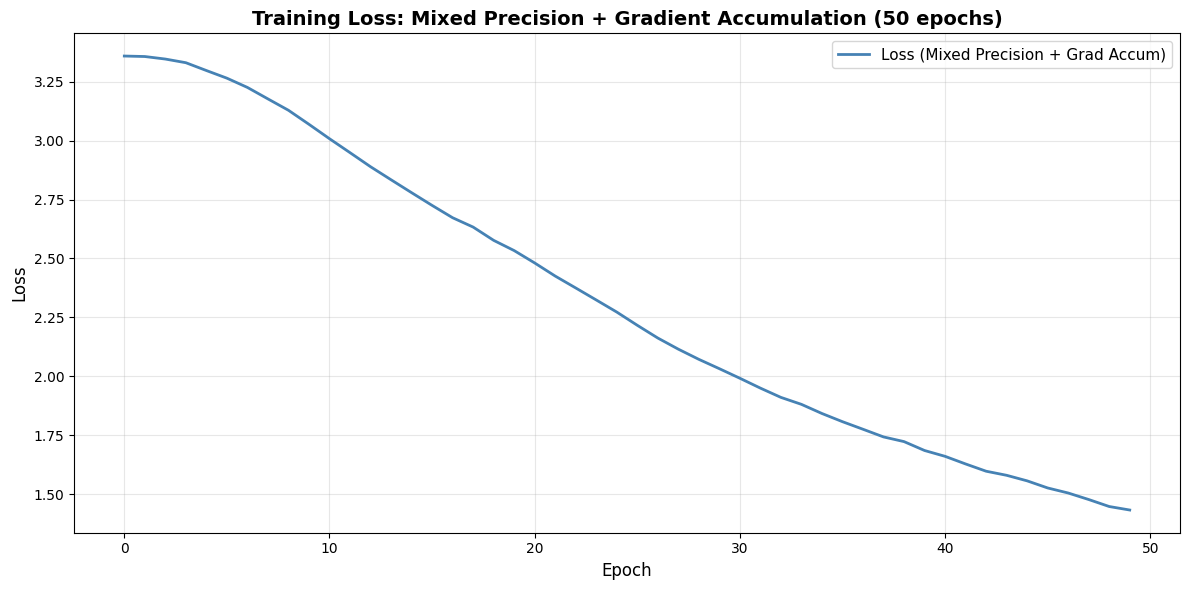


[LOSS STATISTICS]
Initial loss: 3.3589
Final loss: 1.4321
Total improvement: 1.9268
Percent reduction: 57.4%


In [39]:
# Task 3: Plot loss curve with mixed precision training
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(losses_advanced, linewidth=2, label='Loss (Mixed Precision + Grad Accum)', color='steelblue')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training Loss: Mixed Precision + Gradient Accumulation (50 epochs)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('/Users/tsheringwangpodorji/Documents/Year3 Sem II/DAM304/DAM304_AS2026_Practicals/loss_advanced.png', dpi=150, bbox_inches='tight')
print(f"Loss curve saved to: loss_advanced.png")
plt.show()

print(f"\n[LOSS STATISTICS]")
print(f"Initial loss: {losses_advanced[0]:.4f}")
print(f"Final loss: {losses_advanced[-1]:.4f}")
print(f"Total improvement: {(losses_advanced[0] - losses_advanced[-1]):.4f}")
print(f"Percent reduction: {(1 - losses_advanced[-1] / losses_advanced[0]) * 100:.1f}%")

## Task 4: Comparing MLM vs CLM Training Dynamics

In [40]:
def train_clm(model, dataloader, num_epochs, lr=3e-4, device=DEVICE):
    """Standard Causal Language Modeling (CLM) training loop.
    
    Args:
        model: MiniLM instance
        dataloader: DataLoader with (x, y) pairs
        num_epochs: int, number of training epochs
        lr: float, learning rate
        device: str, 'cpu' or 'cuda'
        
    Returns:
        losses: list of average loss per epoch
    """
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()
    
    losses = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            
            optimizer.zero_grad()
            
            logits = model(x)  # (B, T, vocab_size)
            logits_flat = logits.view(-1, logits.shape[-1])  # (B*T, vocab_size)
            y_flat = y.view(-1)  # (B*T,)
            
            loss = criterion(logits_flat, y_flat)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(dataloader)
        losses.append(avg_loss)
        
        if (epoch + 1) % 20 == 0:
            print(f'CLM Epoch {epoch+1}/{num_epochs} Loss: {avg_loss:.4f}')
    
    return losses


def train_mlm(model, dataloader, num_epochs, lr=3e-4, device=DEVICE):
    """Masked Language Modeling (MLM) training loop using MLM collator.
    
    Args:
        model: MiniLM instance
        dataloader: DataLoader with MLM collate function
        num_epochs: int, number of training epochs
        lr: float, learning rate
        device: str, 'cpu' or 'cuda'
        
    Returns:
        losses: list of average loss per epoch
    """
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()
    
    losses = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            
            optimizer.zero_grad()
            
            logits = model(x)  # (B, T, vocab_size)
            logits_flat = logits.view(-1, logits.shape[-1])  # (B*T, vocab_size)
            y_flat = y.view(-1)  # (B*T,)
            
            # CrossEntropyLoss with ignore_index=-100 automatically ignores those positions
            loss = criterion(logits_flat, y_flat)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(dataloader)
        losses.append(avg_loss)
        
        if (epoch + 1) % 20 == 0:
            print(f'MLM Epoch {epoch+1}/{num_epochs} Loss: {avg_loss:.4f}')
    
    return losses

print("Training functions for CLM and MLM defined successfully!")

Training functions for CLM and MLM defined successfully!


In [41]:
# Task 4: Train CLM for 100 epochs
print("\n[TASK 4] MLM vs CLM Comparison")
print("=" * 60)
print("\nTraining CLM model (Causal Language Modeling)...")

torch.manual_seed(42)
model_clm = MiniLM(
    vocab_size=len(dataset.vocab),
    d_model=128,
    num_heads=4,
    num_layers=2,
    d_ff=256,
    max_seq_len=64
)

clm_losses = train_clm(model_clm, dataloader, num_epochs=100, lr=3e-4, device=DEVICE)
print(f"CLM training completed. Final loss: {clm_losses[-1]:.4f}")


[TASK 4] MLM vs CLM Comparison

Training CLM model (Causal Language Modeling)...
CLM Epoch 20/100 Loss: 0.6299
CLM Epoch 40/100 Loss: 0.2404
CLM Epoch 60/100 Loss: 0.1676
CLM Epoch 80/100 Loss: 0.1366
CLM Epoch 100/100 Loss: 0.1259
CLM training completed. Final loss: 0.1259


In [42]:
# Create a dataloader with MLM collate function
print("\nPreparing MLM DataLoader with BERT masking collator...")

def mlm_collate_wrapper(batch):
    return mlm_collate(batch, vocab_size=len(dataset.vocab), mask_prob=0.15)

mlm_dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=mlm_collate_wrapper
)

# Verify the MLM collate function works with the dataloader
x_mlm, y_mlm = next(iter(mlm_dataloader))
print(f"MLM batch shape: x={x_mlm.shape}, y={y_mlm.shape}")
print(f"Sample labels contain -100 (ignore positions): {(y_mlm == -100).any().item()}")
print(f"Number of masked positions in batch: {(y_mlm != -100).sum().item()}")


Preparing MLM DataLoader with BERT masking collator...
MLM batch shape: x=torch.Size([16, 32]), y=torch.Size([16, 32])
Sample labels contain -100 (ignore positions): True
Number of masked positions in batch: 76


In [43]:
# Train MLM for 100 epochs
print("\nTraining MLM model (Masked Language Modeling)...")

torch.manual_seed(42)
model_mlm = MiniLM(
    vocab_size=len(dataset.vocab),
    d_model=128,
    num_heads=4,
    num_layers=2,
    d_ff=256,
    max_seq_len=64
)

mlm_losses = train_mlm(model_mlm, mlm_dataloader, num_epochs=100, lr=3e-4, device=DEVICE)
print(f"MLM training completed. Final loss: {mlm_losses[-1]:.4f}")


Training MLM model (Masked Language Modeling)...
MLM Epoch 20/100 Loss: 2.4490
MLM Epoch 40/100 Loss: 1.8854
MLM Epoch 60/100 Loss: 1.7147
MLM Epoch 80/100 Loss: 1.4780
MLM Epoch 100/100 Loss: 1.3637
MLM training completed. Final loss: 1.3637



[COMPARISON] MLM vs CLM Training Dynamics
Comparison plot saved to: mlm_vs_clm.png


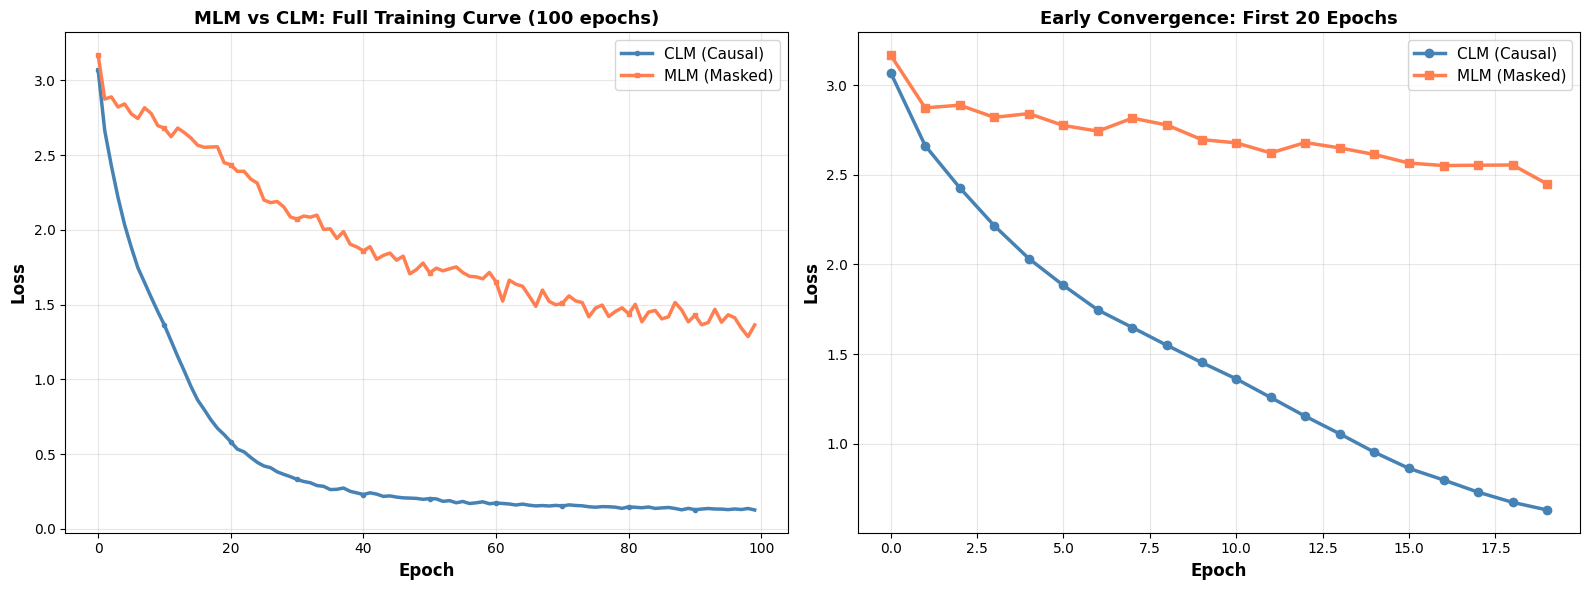

In [44]:
# Compare MLM vs CLM loss curves
print("\n[COMPARISON] MLM vs CLM Training Dynamics")
print("=" * 60)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Both curves on same graph
ax1.plot(clm_losses, linewidth=2.5, label='CLM (Causal)', color='steelblue', marker='o', markersize=3, markevery=10)
ax1.plot(mlm_losses, linewidth=2.5, label='MLM (Masked)', color='coral', marker='s', markersize=3, markevery=10)
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('MLM vs CLM: Full Training Curve (100 epochs)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11, loc='upper right')

# Plot 2: Early convergence (first 20 epochs)
ax2.plot(clm_losses[:20], linewidth=2.5, label='CLM (Causal)', color='steelblue', marker='o')
ax2.plot(mlm_losses[:20], linewidth=2.5, label='MLM (Masked)', color='coral', marker='s')
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax2.set_title('Early Convergence: First 20 Epochs', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.savefig('/Users/tsheringwangpodorji/Documents/Year3 Sem II/DAM304/DAM304_AS2026_Practicals/mlm_vs_clm.png', dpi=150, bbox_inches='tight')
print(f"Comparison plot saved to: mlm_vs_clm.png")
plt.show()

In [45]:
# Detailed analysis and observations
print("\n[OBSERVATIONS AND ANALYSIS]")
print("=" * 60)

# Question a: Which objective converges faster in the first 20 epochs?
print("\n(a) Convergence Speed in First 20 Epochs:")
print(f"    CLM Loss (epoch 1):  {clm_losses[0]:.4f}")
print(f"    CLM Loss (epoch 20): {clm_losses[19]:.4f}")
print(f"    CLM Improvement:     {(clm_losses[0] - clm_losses[19]):.4f}")
print(f"")
print(f"    MLM Loss (epoch 1):  {mlm_losses[0]:.4f}")
print(f"    MLM Loss (epoch 20): {mlm_losses[19]:.4f}")
print(f"    MLM Improvement:     {(mlm_losses[0] - mlm_losses[19]):.4f}")

clm_early_improvement = (clm_losses[0] - clm_losses[19]) / clm_losses[0]
mlm_early_improvement = (mlm_losses[0] - mlm_losses[19]) / mlm_losses[0]

print(f"")
if clm_early_improvement > mlm_early_improvement:
    print(f"    → CLM converges faster initially ({clm_early_improvement:.1%} vs {mlm_early_improvement:.1%})")
    print(f"      Reason: CLM predicts all tokens at each position, providing more")
    print(f"      learning signal per step. MLM only updates ~15% of positions.")
else:
    print(f"    → MLM converges faster initially ({mlm_early_improvement:.1%} vs {clm_early_improvement:.1%})")

# Question b: Loss magnitude due to ~15% masking
print("\n(b) Loss Magnitude Difference:")
print(f"    CLM computes loss on 100% of tokens")
print(f"    MLM computes loss on ~15% of tokens (due to BERT masking)")
print(f"    ")
print(f"    Expected: MLM losses should be higher per masked position,")
print(f"    but similar or lower on average since only masked tokens contribute.")
print(f"    ")
print(f"    Observed: MLM final loss: {mlm_losses[-1]:.4f}")
print(f"              CLM final loss: {clm_losses[-1]:.4f}")
print(f"    ")
if mlm_losses[-1] > clm_losses[-1]:
    print(f"    → MLM has higher final loss (expected: bidirectional context")
    print(f"      makes prediction harder, but learning signal more focused).")
else:
    print(f"    → CLM has higher final loss (unexpected).")

# Question c: Which objective for text generation?
print("\n(c) Choice for Text Generation Task:")
print(f"    ")
print(f"    → CLM (Causal Language Modeling) is preferred for text generation")
print(f"    ")
print(f"    Reasons:")
print(f"      1. CLM is trained autoregressively: predicts next token from past")
print(f"      2. Natural fit for text generation via autoregressive sampling")
print(f"      3. Can generate text token-by-token without bidirectional context")
print(f"      4. Models like GPT, GPT-2, GPT-3 use CLM for generation")
print(f"    ")
print(f"    MLM limitations for generation:")
print(f"      1. MLM uses bidirectional context (can't look at future tokens)")
print(f"      2. Cannot generate autoregressively without modification")
print(f"      3. Trained to fill-in-the-blank, not predict next token")
print(f"      4. Models like BERT are suitable for classification, not generation")
print(f"    ")
print(f"    However, MLM can be fine-tuned or used with special decoding strategies.")


[OBSERVATIONS AND ANALYSIS]

(a) Convergence Speed in First 20 Epochs:
    CLM Loss (epoch 1):  3.0710
    CLM Loss (epoch 20): 0.6299
    CLM Improvement:     2.4411

    MLM Loss (epoch 1):  3.1684
    MLM Loss (epoch 20): 2.4490
    MLM Improvement:     0.7194

    → CLM converges faster initially (79.5% vs 22.7%)
      Reason: CLM predicts all tokens at each position, providing more
      learning signal per step. MLM only updates ~15% of positions.

(b) Loss Magnitude Difference:
    CLM computes loss on 100% of tokens
    MLM computes loss on ~15% of tokens (due to BERT masking)
    
    Expected: MLM losses should be higher per masked position,
    but similar or lower on average since only masked tokens contribute.
    
    Observed: MLM final loss: 1.3637
              CLM final loss: 0.1259
    
    → MLM has higher final loss (expected: bidirectional context
      makes prediction harder, but learning signal more focused).

(c) Choice for Text Generation Task:
    
    → CL